# CNN ile Memorable ve Forgettable Görüntü Sınıflandırması

Bu notebook, bir görüntünün **memorable** ya da **forgettable** olarak sınıflandırılıp sınıflandırılamayacağını CNN modelleriyle inceler. Çalışmada Kaggle'daki **Forgetable Images vs Memorable Images** veri seti kullanılmıştır.

Analizde dört farklı görüntü sürümü karşılaştırılmıştır:

- original grayscale images
- HE: Histogram Equalization
- AHE: Adaptive Histogram Equalization
- CLAHE: Contrast Limited Adaptive Histogram Equalization

İki farklı CNN mimarisi eğitilip karşılaştırılmıştır. Buradaki amaç yalnızca bir skor elde etmek değil, kontrast iyileştirme yöntemlerinin CNN modellerinin öğrenme davranışını nasıl değiştirdiğini gözlemlemektir.

## Proje Özeti

Veri setinde toplam **69.195** etiketlenebilir görüntü bulunmaktadır: **47.302 memorable** ve **21.893 forgettable**. Sınıflar dengeli olmadığı için modelleme aşamasında dengeli bir alt küme kullanılmıştır.

Bu çalıştırmada en iyi sonuç **original images + CNN-1** kombinasyonunda elde edilmiştir:

| Metrik | Değer |
|---|---:|
| Accuracy | 0.8077 |
| Precision | 0.7381 |
| Recall | 0.9538 |
| F1-score | 0.8322 |

Deney, kontrast iyileştirmenin her zaman model başarısını artırmadığını göstermektedir. Bu çalışmada CLAHE, kontrast uygulanmış görüntüler içinde güçlü bir alternatif olmuştur; ancak en yüksek F1-score original imagesle elde edilmiştir.

## 1. Veri Seti ve Keşifsel Veri Analizi

Bu çalışmada Kaggle'daki **Forgetable Images vs Memorable Images** veri kümesi kullanılmıştır. Veri seti iki sınıflı bir görüntü sınıflandırma problemidir.

Sınıflar:

- **memorable:** Akılda kalıcı görüntüler
- **forgettable/forgetable:** Daha kolay unutulabilir görüntüler

Bu çözümde görüntülerden elle özellik çıkarmak yerine CNN kullanılmıştır. CNN modelinin evrişim katmanları görüntüden kenar, doku, kontrast ve şekil örüntülerini otomatik öğrenir. Bu nedenle bu dosya, klasik makine öğrenmesi çözümünden farklı olarak derin öğrenme yaklaşımıdır.

EDA aşamasında sınıf dağılımı, görüntü boyutları, parlaklık/kontrast ilişkisi ve örnek görüntüler incelenmiştir.

In [44]:
import os
import sys
import subprocess
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

RANDOM_STATE = 73
IMG_SIZE = 104
MAX_IMAGES_PER_CLASS = 260
EPOCHS = 5
BATCH_SIZE = 24

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

downloaded_dataset_path = None

import kagglehub

if kagglehub is not None:
        downloaded_dataset_path = Path(kagglehub.dataset_download("pidual2/forgetable-images-vs-memorable-images"))

candidate_roots = [
    downloaded_dataset_path,
    Path("/kaggle/input/datasets/pidual2/forgetable-images-vs-memorable-images")
]

image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def find_images(root):
    if root is None:
        return []
    root = Path(root)
    if not root.exists():
        return []
    return [p for p in root.rglob("*") if p.suffix.lower() in image_exts]

DATA_ROOT = None
all_images = []
for root in candidate_roots:
    imgs = find_images(root)
    if imgs:
        DATA_ROOT = root
        all_images = imgs
        break
print("Toplam görüntü:", len(all_images))

if DATA_ROOT is None or len(all_images) == 0:
    raise FileNotFoundError(
        "Veri seti bulunamadı."
    )

Toplam görüntü: 69195


Etiketlenebilen görüntü sayısı: 69195


,path,label
0,/kaggle/input/datasets/pidual2/forgetable-imag...,memorable
1,/kaggle/input/datasets/pidual2/forgetable-imag...,memorable
2,/kaggle/input/datasets/pidual2/forgetable-imag...,memorable
3,/kaggle/input/datasets/pidual2/forgetable-imag...,memorable
4,/kaggle/input/datasets/pidual2/forgetable-imag...,memorable


,count
label,
memorable,47302
forgettable,21893


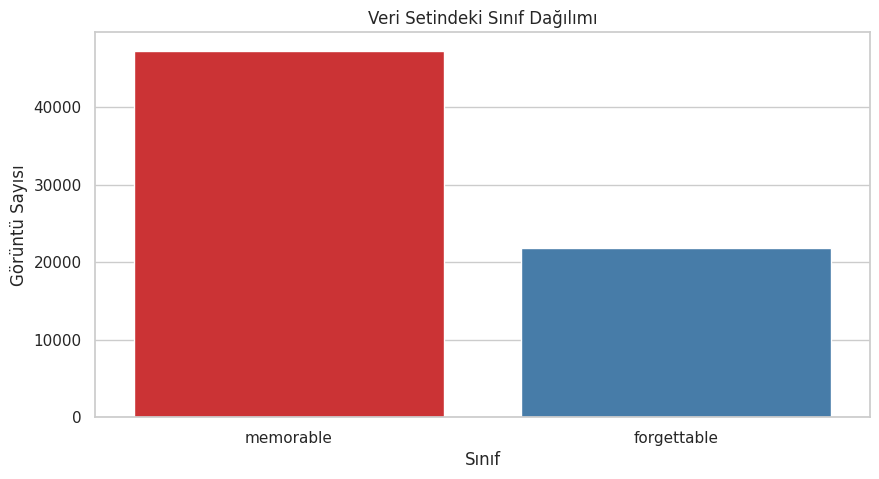

In [45]:
def infer_label(path):
    p = Path(path)
    try:
        parts = p.relative_to(DATA_ROOT).parts[:-1]
    except ValueError:
        parts = p.parts[:-1]

    for part in reversed(parts):
        name = part.lower()
        if "forgettable" in name or "forgetable" in name:
            return "forgettable"
        if "memorable" in name:
            return "memorable"
    return None

records = []
for p in all_images:
    label = infer_label(p)
    if label is not None:
        records.append({"path": str(p), "label": label})

df = pd.DataFrame(records)
print("Etiketlenebilen görüntü sayısı:", len(df))
display(df.head())
display(df["label"].value_counts().to_frame("count"))

if df.empty:
    raise ValueError("Sınıf etiketi çıkarılamadı. Klasör adlarında memorable/forgetable ifadelerini kontrol edin.")

sns.countplot(data=df, x="label", hue="label", legend=False, palette="Set1")
plt.title("Veri Setindeki Sınıf Dağılımı")
plt.xlabel("Sınıf")
plt.ylabel("Görüntü Sayısı")
plt.show()

,height,width,aspect_ratio,brightness,contrast
count,450.000000,450.000000,450.000000,450.000000,450.000000
mean,521.091111,541.342222,1.173788,118.753817,63.971207
std,358.101040,250.690660,0.411197,43.118863,15.872516
min,176.000000,236.000000,0.404858,15.885207,14.914373
25%,335.000000,484.000000,0.764500,89.777876,54.420579
50%,415.500000,500.000000,1.333333,112.588054,63.386262
75%,511.750000,522.500000,1.501502,136.258060,73.146988
max,3840.000000,3579.000000,3.512048,249.780085,123.454195


,brightness,contrast,aspect_ratio
label,,,
forgettable,128.672,68.925,1.000
memorable,107.238,61.354,1.333


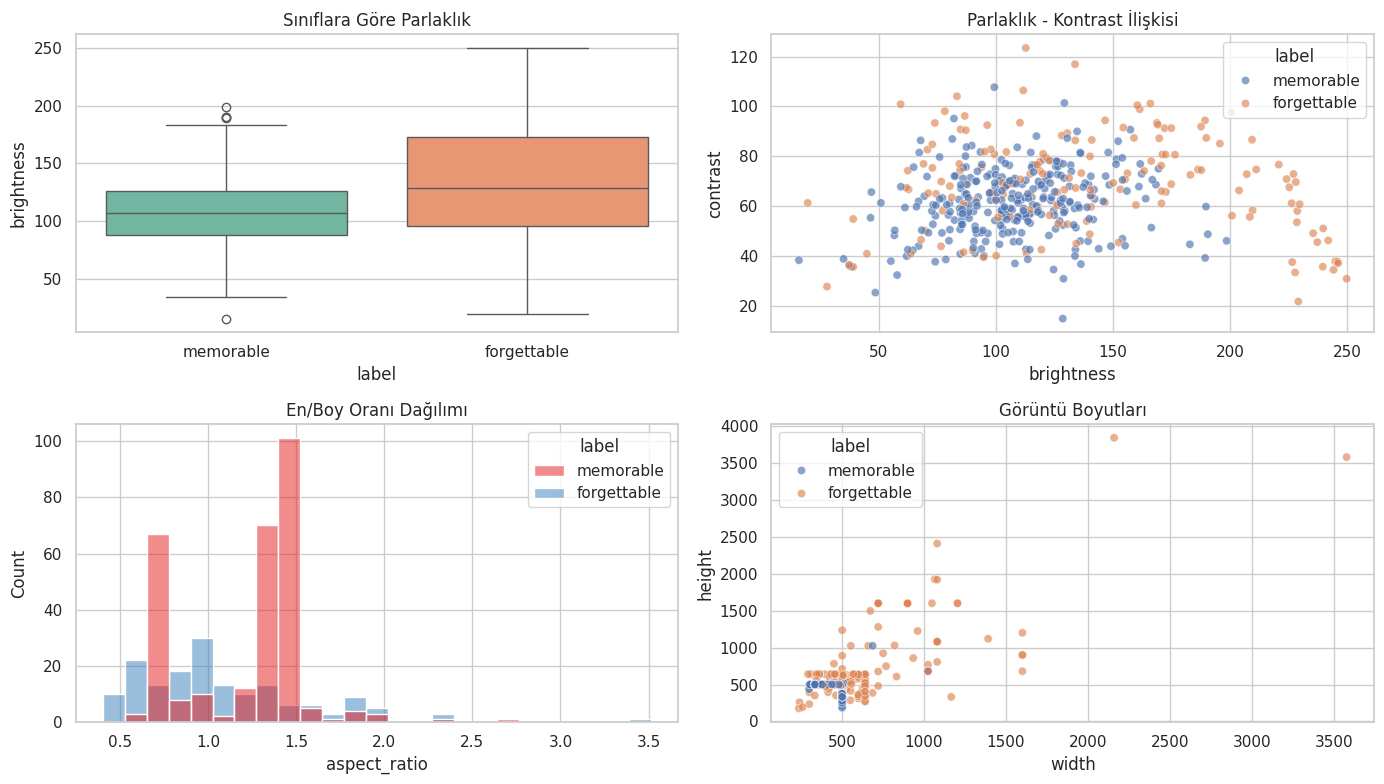

In [46]:
# Görüntü okuma ve temel EDA
def read_gray(path, size=None):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Okunamayan görüntü: {path}")
    if size is not None:
        img = cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)
    return img

eda_rows = []
eda_sample = df.sample(min(450, len(df)), random_state=RANDOM_STATE + 2)
for _, row in eda_sample.iterrows():
    img = read_gray(row["path"])
    h, w = img.shape
    eda_rows.append({
        "label": row["label"],
        "height": h,
        "width": w,
        "aspect_ratio": w / h,
        "brightness": img.mean(),
        "contrast": img.std(),
    })

eda_df = pd.DataFrame(eda_rows)
display(eda_df.describe())
display(eda_df.groupby("label")[["brightness", "contrast", "aspect_ratio"]].median().round(3))

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
sns.boxplot(data=eda_df, x="label", y="brightness", hue="label", legend=False, ax=axes[0, 0], palette="Set2")
axes[0, 0].set_title("Sınıflara Göre Parlaklık")
sns.scatterplot(data=eda_df, x="brightness", y="contrast", hue="label", alpha=0.65, ax=axes[0, 1])
axes[0, 1].set_title("Parlaklık - Kontrast İlişkisi")
sns.histplot(data=eda_df, x="aspect_ratio", hue="label", bins=25, ax=axes[1, 0], palette="Set1")
axes[1, 0].set_title("En/Boy Oranı Dağılımı")
sns.scatterplot(data=eda_df, x="width", y="height", hue="label", alpha=0.65, ax=axes[1, 1])
axes[1, 1].set_title("Görüntü Boyutları")
plt.tight_layout()
plt.show()

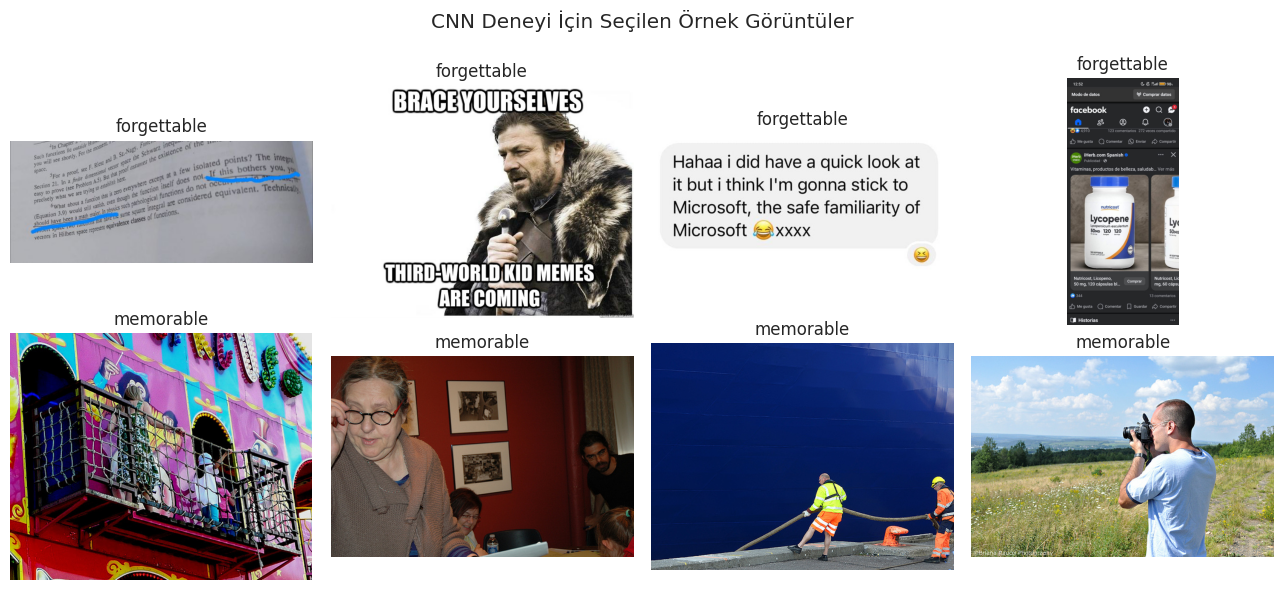

In [47]:
# Örnek görüntüler
sample_df = df.groupby("label", group_keys=False).apply(
    lambda x: x.sample(min(4, len(x)), random_state=RANDOM_STATE + 19)
)

fig, axes = plt.subplots(2, 4, figsize=(13, 6))
axes = axes.ravel()

for ax, (_, row) in zip(axes, sample_df.iterrows()):
    img = cv2.cvtColor(cv2.imread(row["path"]), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(row["label"])
    ax.axis("off")

for ax in axes[len(sample_df):]:
    ax.axis("off")

plt.suptitle("CNN Deneyi İçin Seçilen Örnek Görüntüler")
plt.tight_layout()
plt.show()

EDA aşaması, veri setinin büyük olduğunu ve sınıfların tam dengeli olmadığını göstermektedir. Bu nedenle CNN eğitiminde modelin çoğunluk sınıfına yönelmesini azaltmak için dengeli bir alt küme kullanılmıştır.

Bu bölümde görüntü boyutları, parlaklık-kontrast ilişkisi, en/boy oranı ve örnek görüntüler incelenmiştir.

## 2. Image Preprocessing

CNN modelleri sabit boyutta görüntü beklediği için tüm görseller 104x104 boyutuna getirilmiştir. Görüntüler gri tona çevrilmiş ve piksel değerleri 0-1 aralığına normalize edilmiştir.

Bu çalışmada üç histogram equalization yöntemi kullanılmıştır:

- **HE:** Global Histogram Equalization.
- **AHE:** Adaptive Histogram Equalization.
- **CLAHE:** Contrast Limited Adaptive Histogram Equalization.

Bu yöntemler görüntü kontrastını değiştirerek CNN'in öğrendiği görsel örüntüleri etkileyebilir. Bu yüzden her yöntem için ayrı eğitim ve test deneyi yapılmıştır.

In [49]:
# HE / AHE / CLAHE fonksiyonları
def apply_he(gray):
    return cv2.equalizeHist(gray)

def apply_ahe(gray, tile_grid_size=(8, 8)):
    # AHE: görüntüyü küçük bölgelere ayırıp her bölgeye ayrı histogram eşitleme uygular.
    # CLAHE'den farkı kontrast sınırlaması (clip limit) kullanmamasıdır.
    h, w = gray.shape
    tiles_x, tiles_y = tile_grid_size
    tile_h = int(np.ceil(h / tiles_y))
    tile_w = int(np.ceil(w / tiles_x))
    result = np.zeros_like(gray)

    for y in range(0, h, tile_h):
        for x in range(0, w, tile_w):
            tile = gray[y:min(y + tile_h, h), x:min(x + tile_w, w)]
            result[y:min(y + tile_h, h), x:min(x + tile_w, w)] = cv2.equalizeHist(tile)
    return result

def apply_clahe(gray, clip_limit=2.0, tile_grid_size=(8, 8)):
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    return clahe.apply(gray)

preprocess_methods = {
    "original": lambda x: x,
    "HE": apply_he,
    "AHE": apply_ahe,
    "CLAHE": apply_clahe,
}

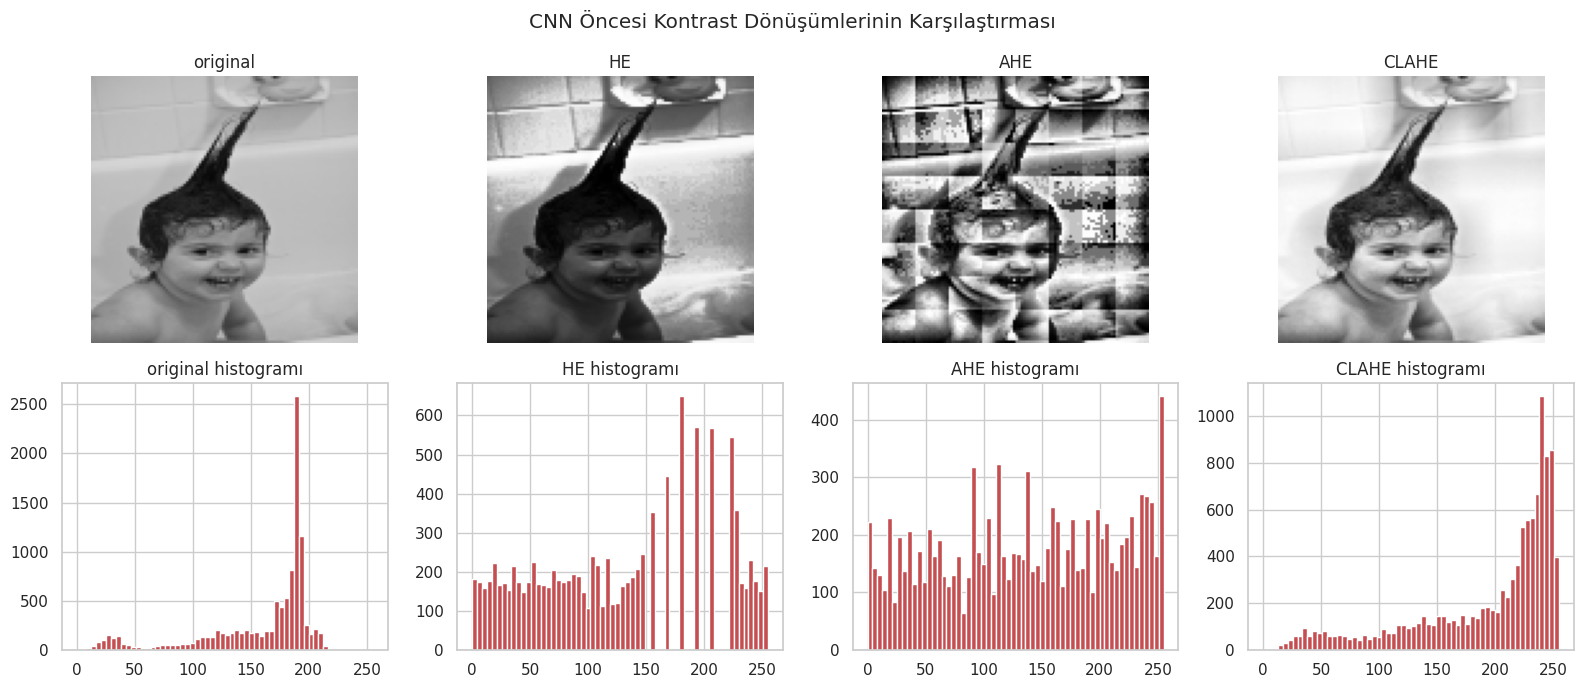

In [50]:
# Ön işleme yöntemlerini görsel ve histogram olarak karşılaştırma
example_path = df.sample(1, random_state=RANDOM_STATE + 31).iloc[0]["path"]
example = read_gray(example_path, IMG_SIZE)

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for i, (name, func) in enumerate(preprocess_methods.items()):
    processed = func(example)
    axes[0, i].imshow(processed, cmap="gray", vmin=0, vmax=255)
    axes[0, i].set_title(name)
    axes[0, i].axis("off")
    axes[1, i].hist(processed.ravel(), bins=60, range=(0, 255), color="#C44E52")
    axes[1, i].set_title(f"{name} histogramı")

plt.suptitle("CNN Öncesi Kontrast Dönüşümlerinin Karşılaştırması")
plt.tight_layout()
plt.show()

brightness         contrast              p90        
               mean     std     mean     std     mean     std
method                                                       
AHE         133.460  16.185   77.410   5.672  236.950   8.659
CLAHE       138.967  41.411   64.861  13.408  223.180  32.382
HE          129.895  14.726   75.780   7.010  233.202   9.086
original    118.343  45.275   58.983  15.986  196.745  46.530

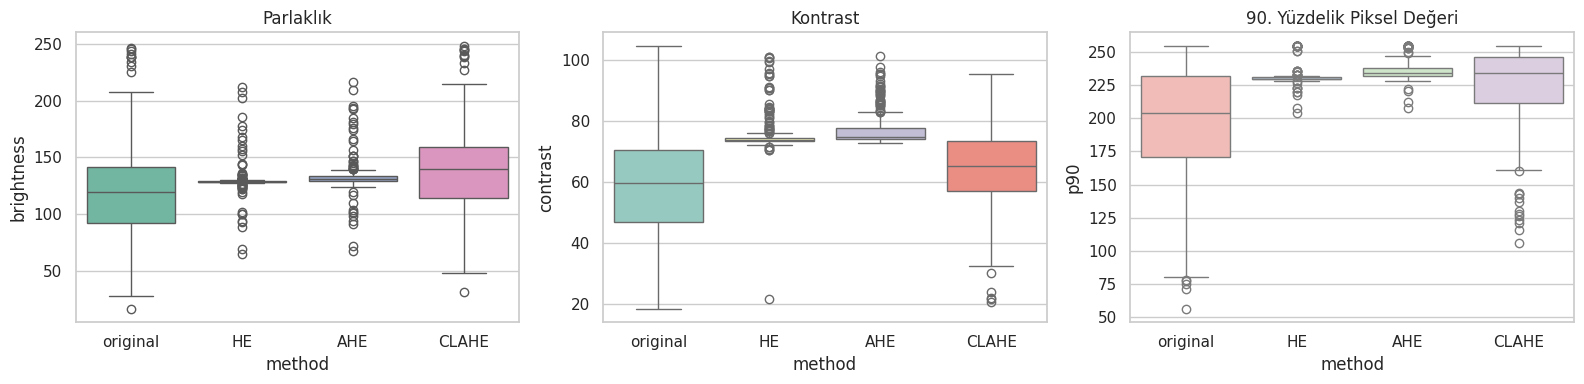

In [51]:
# Yöntemlere göre ortalama parlaklık ve kontrast değişimi
rows = []
for p in df["path"].sample(min(220, len(df)), random_state=RANDOM_STATE + 5):
    gray = read_gray(p, IMG_SIZE)
    for method_name, func in preprocess_methods.items():
        out_img = func(gray)
        rows.append({
            "method": method_name,
            "brightness": out_img.mean(),
            "contrast": out_img.std(),
            "p90": np.percentile(out_img, 90),
        })

prep_stats = pd.DataFrame(rows)
display(prep_stats.groupby("method").agg(["mean", "std"]).round(3))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.boxplot(data=prep_stats, x="method", y="brightness", hue="method", legend=False, ax=axes[0], palette="Set2")
axes[0].set_title("Parlaklık")
sns.boxplot(data=prep_stats, x="method", y="contrast", hue="method", legend=False, ax=axes[1], palette="Set3")
axes[1].set_title("Kontrast")
sns.boxplot(data=prep_stats, x="method", y="p90", hue="method", legend=False, ax=axes[2], palette="Pastel1")
axes[2].set_title("90. Yüzdelik Piksel Değeri")
plt.tight_layout()
plt.show()

Preprocessing karşılaştırması, histogram equalization yöntemlerinin görüntülerin parlaklık ve kontrast dağılımını değiştirdiğini göstermektedir. Bu farklı image versions ayrı ayrı test edilerek contrast enhancement işlemlerinin CNN modellerine yardımcı olup olmadığı incelenmiştir.

## 3. CNN Modelleme

Bu çalışmada özellikler CNN tarafından otomatik öğrenilmiştir. Evrişim katmanları görüntüdeki kenar, doku ve kontrast geçişlerini öğrenebildiği için görsel veri üzerinde uygundur.

İki model kullanılmıştır:

- **CNN-1:** Daha sade ve hızlı bir modeldir.
- **CNN-2:** Batch normalization ve global average pooling içeren daha derin bir modeldir.

Her sınıftan 260 görüntü alınarak dengeli bir alt küme oluşturulmuştur. Original, HE, AHE ve CLAHE versiyonları için modeller ayrı ayrı eğitilmiş ve sonuçları karşılaştırılmıştır.

In [52]:
# Dengeli veri alt kümesi ve train/test ayrımı
balanced_parts = []
for label, part in df.groupby("label"):
    balanced_parts.append(part.sample(min(MAX_IMAGES_PER_CLASS, len(part)), random_state=RANDOM_STATE))

work_df = pd.concat(balanced_parts).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
work_df["target"] = work_df["label"].map({"forgettable": 0, "memorable": 1})

train_df, test_df = train_test_split(
    work_df,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=work_df["target"],
)

print("Eğitim görüntü sayısı:", len(train_df))
print("Test görüntü sayısı:", len(test_df))
display(work_df["label"].value_counts().to_frame("count"))

Eğitim görüntü sayısı: 390
Test görüntü sayısı: 130


,count
label,
forgettable,260
memorable,260


In [53]:
# CNN için görüntü dizisi hazırlama
def dataframe_to_arrays(input_df, method_name):
    func = preprocess_methods[method_name]
    X, y = [], []
    for _, row in input_df.iterrows():
        try:
            gray = read_gray(row["path"], IMG_SIZE)
            gray = func(gray)
            gray = gray.astype("float32") / 255.0
            X.append(gray[..., np.newaxis])
            y.append(row["target"])
        except Exception as exc:
            print("Atlanan dosya:", row["path"], exc)
    return np.array(X, dtype="float32"), np.array(y, dtype="int32")

def build_cnn_1():
    model = models.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1)),
        layers.Conv2D(16, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Conv2D(32, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.30),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

def build_cnn_2():
    model = models.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1)),
        layers.Conv2D(24, 3, activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Conv2D(48, 3, activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Conv2D(96, 3, activation="relu", padding="same"),
        layers.GlobalAveragePooling2D(),
        layers.Dense(96, activation="relu"),
        layers.Dropout(0.40),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

model_builders = {
    "CNN-1": build_cnn_1,
    "CNN-2": build_cnn_2,
}

In [54]:
# Modelleri eğitme ve değerlendirme
results = []
histories = {}
predictions = {}

early_stop = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)

for method_name in preprocess_methods.keys():
    print("\nÖn işleme:", method_name)
    X_train, y_train = dataframe_to_arrays(train_df, method_name)
    X_test, y_test = dataframe_to_arrays(test_df, method_name)

    for model_name, builder in model_builders.items():
        print("Model:", model_name)
        model = builder()
        history = model.fit(
            X_train,
            y_train,
            validation_split=0.20,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            callbacks=[early_stop],
            verbose=0,
        )

        proba = model.predict(X_test, verbose=0).ravel()
        pred = (proba >= 0.5).astype(int)

        row = {
            "preprocessing": method_name,
            "model": model_name,
            "accuracy": accuracy_score(y_test, pred),
            "precision": precision_score(y_test, pred, zero_division=0),
            "recall": recall_score(y_test, pred, zero_division=0),
            "f1": f1_score(y_test, pred, zero_division=0),
        }
        results.append(row)
        histories[(method_name, model_name)] = history
        predictions[(method_name, model_name)] = {"y_test": y_test, "pred": pred, "proba": proba}

results_df = pd.DataFrame(results).sort_values("f1", ascending=False).reset_index(drop=True)
display(results_df)


Ön işleme: original
Model: CNN-1


Model: CNN-2

Ön işleme: HE
Model: CNN-1
Model: CNN-2

Ön işleme: AHE
Model: CNN-1
Model: CNN-2

Ön işleme: CLAHE
Model: CNN-1
Model: CNN-2


,preprocessing,model,accuracy,precision,recall,f1
0,original,CNN-1,0.807692,0.738095,0.953846,0.832215
1,CLAHE,CNN-1,0.769231,0.710843,0.907692,0.797297
2,AHE,CNN-1,0.707692,0.631068,1.000000,0.773810
3,HE,CNN-1,0.707692,0.642105,0.938462,0.762500
4,AHE,CNN-2,0.661538,0.610526,0.892308,0.725000
5,CLAHE,CNN-2,0.669231,0.648649,0.738462,0.690647
6,original,CNN-2,0.669231,0.661765,0.692308,0.676692
7,HE,CNN-2,0.507692,0.666667,0.030769,0.058824


In [ ]:
# Model ve ön işleme karşılaştırma grafikleri
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(data=results_df, x="preprocessing", y="accuracy", hue="model", ax=axes[0], palette="Set2")
axes[0].set_ylim(0, 1)
axes[0].set_title("Accuracy Karşılaştırması")
sns.barplot(data=results_df, x="preprocessing", y="f1", hue="model", ax=axes[1], palette="Set3")
axes[1].set_ylim(0, 1)
axes[1].set_title("F1 Karşılaştırması")
plt.tight_layout()
plt.show()

Model karşılaştırması, bu çalıştırmada CNN-1 modelinin CNN-2 modelinden daha başarılı olduğunu göstermektedir. En iyi kombinasyon original images + CNN-1 olmuştur. Bu sonuç, daha güçlü preprocessing işleminin her zaman daha iyi performans anlamına gelmediğini göstermektedir.

## 4. Best Model ve Sonuçların Yorumlanması

En başarılı model F1 skoruna göre seçilmiştir. F1 skoru precision ve recall değerlerini birlikte değerlendirdiği için ikili sınıflandırma problemlerinde tek başına accuracy değerinden daha açıklayıcıdır.

CNN eğitimi epoch bazlı olduğu için en iyi modelin eğitim/doğrulama loss ve accuracy grafikleri çizilmiştir. Ayrıca confusion matrix ile modelin iki sınıfta yaptığı doğru ve yanlış tahminler incelenmiştir.

En iyi ön işleme: original
En iyi model: CNN-1
Accuracy: 0.8077
Precision: 0.7381
Recall: 0.9538
F1: 0.8322

Sınıflandırma raporu:
              precision    recall  f1-score   support

 forgettable       0.93      0.66      0.77        65
   memorable       0.74      0.95      0.83        65

    accuracy                           0.81       130
   macro avg       0.84      0.81      0.80       130
weighted avg       0.84      0.81      0.80       130



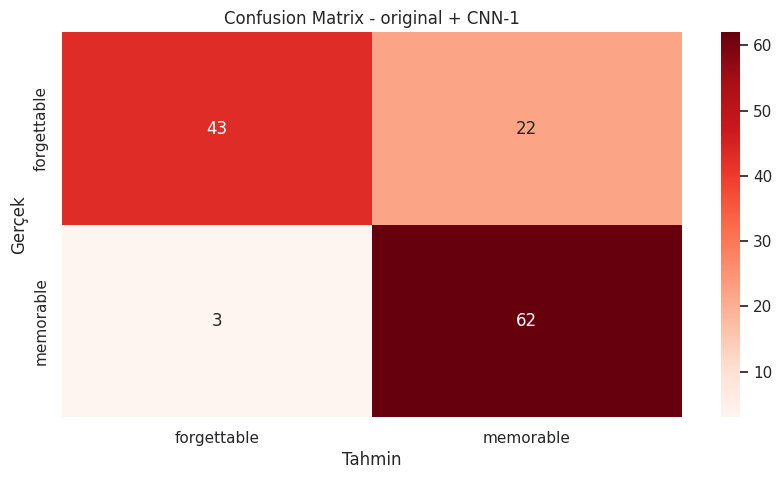

In [55]:
# En iyi sonucu analiz etme
best = results_df.iloc[0]
best_key = (best["preprocessing"], best["model"])
best_pred = predictions[best_key]
best_history = histories[best_key]

print("En iyi ön işleme:", best["preprocessing"])
print("En iyi model:", best["model"])
print("Accuracy:", round(best["accuracy"], 4))
print("Precision:", round(best["precision"], 4))
print("Recall:", round(best["recall"], 4))
print("F1:", round(best["f1"], 4))

print("\nSınıflandırma raporu:")
print(classification_report(best_pred["y_test"], best_pred["pred"], target_names=["forgettable", "memorable"], zero_division=0))

cm = confusion_matrix(best_pred["y_test"], best_pred["pred"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds", xticklabels=["forgettable", "memorable"], yticklabels=["forgettable", "memorable"])
plt.title(f"Confusion Matrix - {best['preprocessing']} + {best['model']}")
plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.show()

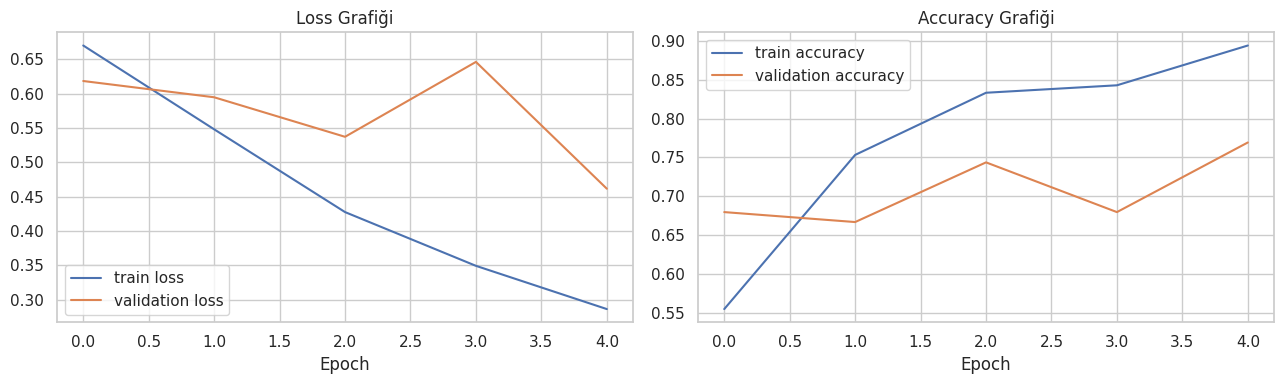

,preprocessing,model,accuracy,precision,recall,f1
0,original,CNN-1,0.8077,0.7381,0.9538,0.8322
1,CLAHE,CNN-1,0.7692,0.7108,0.9077,0.7973
2,AHE,CNN-1,0.7077,0.6311,1.0000,0.7738
3,HE,CNN-1,0.7077,0.6421,0.9385,0.7625
4,AHE,CNN-2,0.6615,0.6105,0.8923,0.7250
5,CLAHE,CNN-2,0.6692,0.6486,0.7385,0.6906
6,original,CNN-2,0.6692,0.6618,0.6923,0.6767
7,HE,CNN-2,0.5077,0.6667,0.0308,0.0588


In [56]:
# Eğitim ve doğrulama loss/accuracy grafikleri
history_df = pd.DataFrame(best_history.history)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history_df["loss"], label="train loss")
axes[0].plot(history_df["val_loss"], label="validation loss")
axes[0].set_title("Loss Grafiği")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history_df["accuracy"], label="train accuracy")
axes[1].plot(history_df["val_accuracy"], label="validation accuracy")
axes[1].set_title("Accuracy Grafiği")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

display(results_df.round(4))

Genel olarak en iyi sonuç, original grayscale images ve CNN-1 modeliyle elde edilmiştir. CLAHE, contrast-enhanced images arasında güçlü bir alternatif olsa da bu deneyde original image distribution seçilen CNN yapısı için daha uygun sonuç vermiştir.

Sonraki çalışmalarda renkli görüntüler, daha büyük eğitim alt kümeleri, veri artırma ve MobileNet ya da EfficientNet gibi transfer öğrenme modelleri denenebilir.